# 3D RM-synthesis with Stokes I correction

Builds on the [3D RM-synthesis](rmsynth_3d.ipynb) notebook and adds the optional per-pixel Stokes I correction.

A Stokes I spectral index reweights the polarised signal across $\lambda^2$. That changes the FDF's effective RMSF, so it no longer matches the `rmsf_cube` the tool reports (built from the channel weights alone). RM-CLEAN and the moments assume `rmsf_cube`, so the mismatch biases them. The fix is the same as in 1D: divide by a Stokes I model to get fractional spectra $q = Q/I$, $u = U/I$, run RM-synthesis, then rescale the FDF back to flux by the Stokes I at the reference frequency.

In [1]:
from __future__ import annotations

import dask.array as da
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import quantity_support

plt.rcParams["figure.dpi"] = 150
_ = quantity_support()
rng = np.random.default_rng(42)

Simulate a small cube with RACS-all frequency coverage. The intrinsic fractional polarisation is flat (the same at every pixel), so a correct pipeline recovers a flat fractional-polarisation map whatever the Stokes I does. The RM varies across the field.

In [2]:
from rm_lite.utils.fitting import gaussian
from rm_lite.utils.synthesis import faraday_simple_spectrum

bw_low = 288
freqs = np.linspace(943.5 - bw_low / 2, 943.5 + bw_low / 2, 36) * u.MHz
freq_hz = freqs.to(u.Hz).value

ny, nx = 48, 48
y_grid, x_grid = np.mgrid[0:ny, 0:nx]
blob_y, blob_x = ny * 0.35, nx * 0.65
blob2_y, blob2_x = ny * 0.7, nx * 0.3

rm_map = (
    60.0 * (x_grid / nx - 0.5) * 2
    + np.exp(-((x_grid - blob_x) ** 2 + (y_grid - blob_y) ** 2) / (2 * 4.0**2))
)
psi0_deg = 30.0

frac_pol_true = 0.1  # intrinsic fractional polarisation: a FLAT map
q_frac = np.empty((freq_hz.size, ny, nx), dtype=np.float32)
u_frac = np.empty((freq_hz.size, ny, nx), dtype=np.float32)
for j in range(ny):
    for i in range(nx):
        cs = faraday_simple_spectrum(
            freq_hz, frac_pol=frac_pol_true, psi0_deg=psi0_deg, rm_radm2=rm_map[j, i]
        )
        q_frac[:, j, i] = cs.real
        u_frac[:, j, i] = cs.imag

Stokes I: two Gaussian blobs on empty sky, with a spectral index that varies across the field. None of this is Faraday structure, but it distorts an uncorrected FDF.

[Text(0.5, 1.0, 'Input RM')]

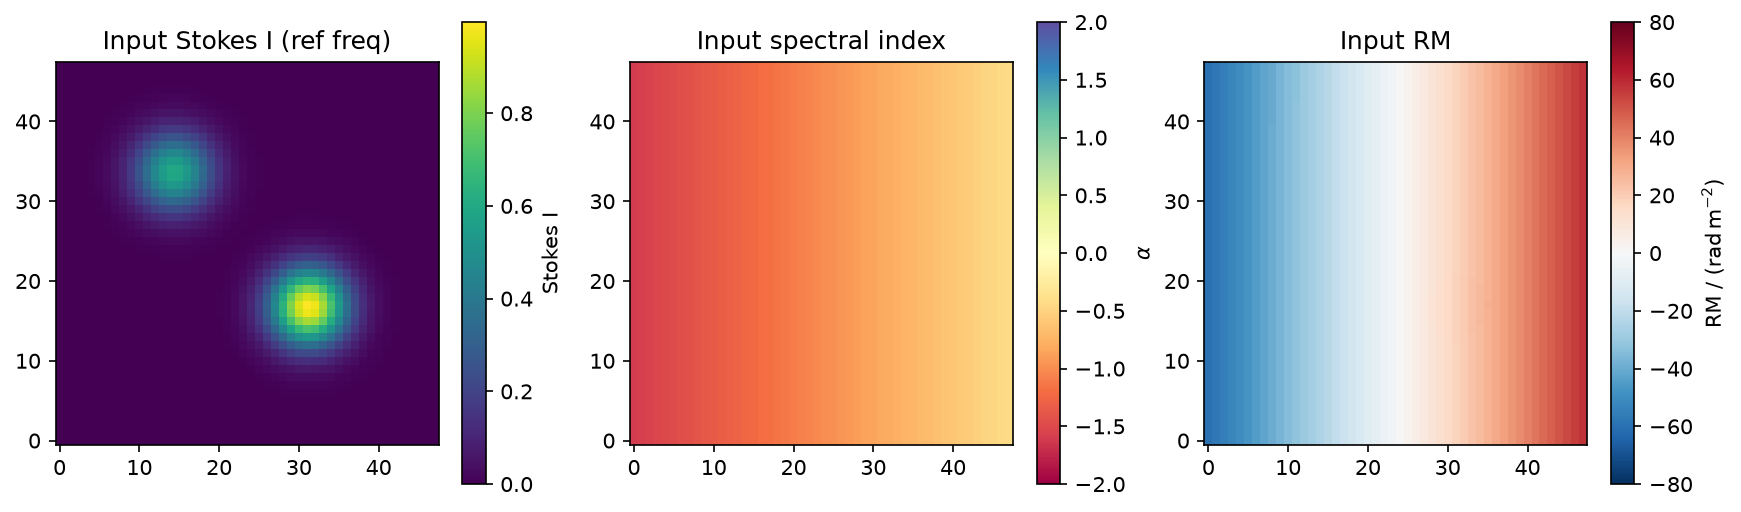

In [3]:
ref_freq_hz = float(np.median(freq_hz))
radius = np.hypot(x_grid - blob_x, y_grid - blob_y)
radius2 = np.hypot(x_grid - blob2_x, y_grid - blob2_y)
i_ref_map = (
    0.0
    + gaussian(radius, amplitude=1.0, mean=0.0, fwhm=8.0)
    + gaussian(radius2, amplitude=0.6, mean=0.0, fwhm=8.0)
)
alpha_map_true = -1.0 + 0.6 * (x_grid / nx - 0.5) * 2  # ~ -1.6 .. -0.4
stokes_i = (
    i_ref_map[None] * (freq_hz / ref_freq_hz)[:, None, None] ** alpha_map_true[None]
).astype(np.float32)

rms_noise = 0.02
stokes_q_obs = q_frac * stokes_i + rng.normal(0, rms_noise, stokes_i.shape).astype(np.float32)
stokes_u_obs = u_frac * stokes_i + rng.normal(0, rms_noise, stokes_i.shape).astype(np.float32)
stokes_i_obs = stokes_i + rng.normal(0, rms_noise, stokes_i.shape).astype(np.float32)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
im1 = ax1.imshow(i_ref_map, origin="lower")
fig.colorbar(im1, ax=ax1, label="Stokes I")
ax1.set(title="Input Stokes I (ref freq)")
im2 = ax2.imshow(alpha_map_true, origin="lower", cmap="Spectral", vmin=-2, vmax=+2)
fig.colorbar(im2, ax=ax2, label=r"$\alpha$")
ax2.set(title="Input spectral index")
im3 = ax3.imshow(rm_map, origin="lower", cmap="RdBu_r", vmin=-80, vmax=80)
fig.colorbar(im3, ax=ax3, label=f"RM / ({u.rad / u.m**2:latex_inline})")
ax3.set(title="Input RM")

Pass the Stokes I cube as `stokes_i`. `rmsynth_3d` fits a model per pixel (the same fitter as 1D), forms the fractional spectra, runs RM-synthesis, and rescales back to flux. The fit is quiet at cube scale. Pass a ready-made `stokes_i_model` cube to skip fitting.

`fit_order=-2` iterates orders 0 to 2 and keeps the best by AIC. `stokes_i_snr_cut=5` fits only pixels above SNR 5 (see below).

In [4]:
from rm_lite.tools_3d.rmsynth import rmsynth_3d

chunks = (-1, 16, 16)
result_i = rmsynth_3d(
    da.from_array(stokes_q_obs, chunks=chunks),
    da.from_array(stokes_u_obs, chunks=chunks),
    freq_hz,
    stokes_i=da.from_array(stokes_i_obs, chunks=chunks),
    estimate_stokes_i_noise=True,  # per-channel noise from the I cube for the fit
    fit_function="log",  # power-law fit
    fit_order=-2,  # iterate orders 0..2, keep the best by AIC
    stokes_i_snr_cut=5.0,  # only fit pixels above SNR 5
    phi_max_radm2=150.0,
    d_phi_radm2=1.0,
    weight_type="uniform",
)
model_cube = result_i.stokes_i_model_cube.compute()

INFO dask_io.estimate_stokes_i_channel_noise: Rechunking Stokes I to one spatial block per channel for noise estimation.
INFO dask_io.estimate_stokes_i_channel_noise: Per-channel noise estimation completed in 0.00472 seconds.


`rmsynth_3d` also returns two 2D Stokes I maps, like the moment maps: the model at the reference frequency (`stokes_i_ref_flux_map`) and the fitted spectral index (`stokes_i_alpha_map`). The fit tracks the observed Stokes I at a bright pixel, and the recovered maps match the inputs.

[Text(0.5, 1.0, 'Recovered spectral index')]

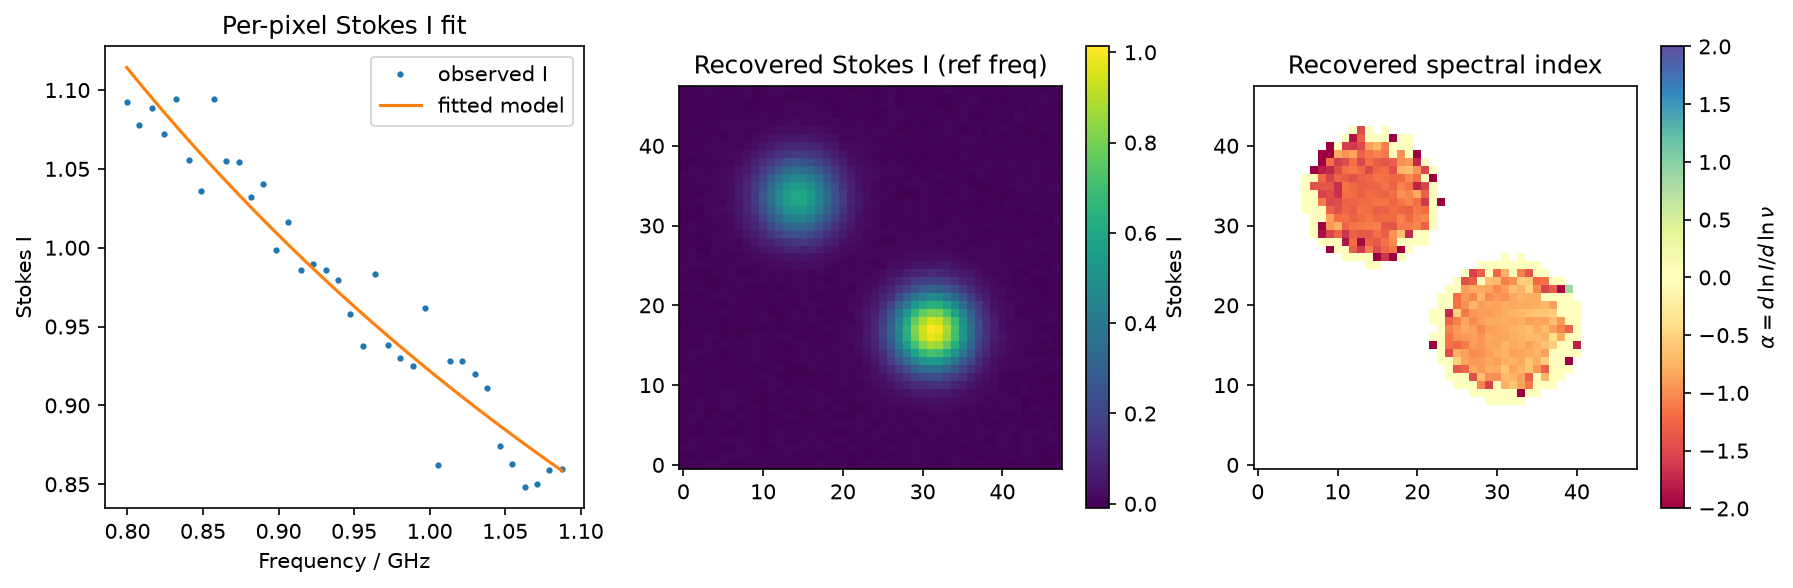

In [5]:
jb, ib = int(blob_y), int(blob_x)  # a bright pixel
ref_flux_map = result_i.stokes_i_ref_flux_map.compute()
alpha_map = result_i.stokes_i_alpha_map.compute()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
ax1.plot(freq_hz / 1e9, stokes_i_obs[:, jb, ib], ".", ms=4, label="observed I")
ax1.plot(freq_hz / 1e9, model_cube[:, jb, ib], "-", label="fitted model")
ax1.set(xlabel="Frequency / GHz", ylabel="Stokes I", title="Per-pixel Stokes I fit")
ax1.legend()
im2 = ax2.imshow(ref_flux_map, origin="lower")
fig.colorbar(im2, ax=ax2, label="Stokes I")
ax2.set(title="Recovered Stokes I (ref freq)")
im3 = ax3.imshow(alpha_map, origin="lower", cmap="Spectral", vmin=-2, vmax=+2)
fig.colorbar(im3, ax=ax3, label=r"$\alpha = d\,\ln I / d\,\ln \nu$")
ax3.set(title="Recovered spectral index")

### Recovering the flat fractional-polarisation map

The corrected FDF is in flux units, so its peak follows the Stokes I brightness and says nothing on its own about fractional polarisation. Divide the peak by the reference Stokes I map (`stokes_i_ref_flux_map`) to get the intrinsic fractional polarisation: flat at `frac_pol_true`, as put in, whatever the Stokes I brightness and index.

recovered fractional pol over source: median=0.120, input=0.1


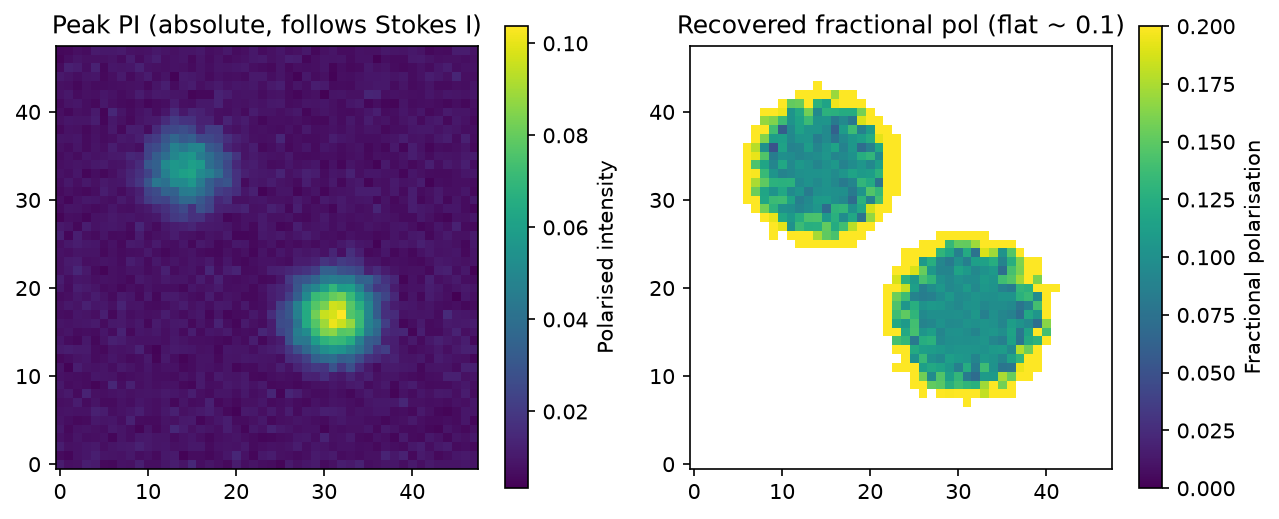

In [6]:
snr_map = np.mean(stokes_i_obs, axis=0) * np.sqrt(freq_hz.size) / rms_noise
source = snr_map >= 5.0  # where the Stokes I fit was applied

fdf_i = result_i.fdf_dirty_cube.compute()
peak_pi_corrected = np.max(np.abs(fdf_i), axis=0)
# Fractional pol is only meaningful where there is Stokes I signal.
frac_pol_recovered = np.where(source, peak_pi_corrected / ref_flux_map, np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
im1 = ax1.imshow(peak_pi_corrected, origin="lower")
fig.colorbar(im1, ax=ax1, label="Polarised intensity")
ax1.set(title="Peak PI (absolute, follows Stokes I)")
im2 = ax2.imshow(frac_pol_recovered, origin="lower", vmin=0, vmax=2 * frac_pol_true)
fig.colorbar(im2, ax=ax2, label="Fractional polarisation")
ax2.set(title=f"Recovered fractional pol (flat ~ {frac_pol_true})")
print(
    f"recovered fractional pol over source: "
    f"median={np.nanmedian(frac_pol_recovered):.3f}, input={frac_pol_true}"
)

### Masking low-SNR pixels

Fitting a Stokes I model to a noise pixel is pointless and can inject fake spectral structure. `rmsynth_3d` fits only pixels whose frequency-averaged Stokes I SNR, `mean(I) * sqrt(N) / rms(noise)`, is at least `stokes_i_snr_cut` (default 5). Below the cut, or if a fit fails to converge, the pixel gets a flat model at its mean: no spectral correction, so its FDF is the plain Q/U FDF. Nothing is blanked.

Most of this field is empty sky. With the cut, only the sources are fitted. Without it (`stokes_i_snr_cut=None`) every noise pixel is fitted too, and the spectral-index map fills with junk.

INFO dask_io.estimate_stokes_i_channel_noise: Rechunking Stokes I to one spatial block per channel for noise estimation.
INFO dask_io.estimate_stokes_i_channel_noise: Per-channel noise estimation completed in 0.00431 seconds.


[Text(0.5, 1.0, 'alpha, no cut (fit all)')]

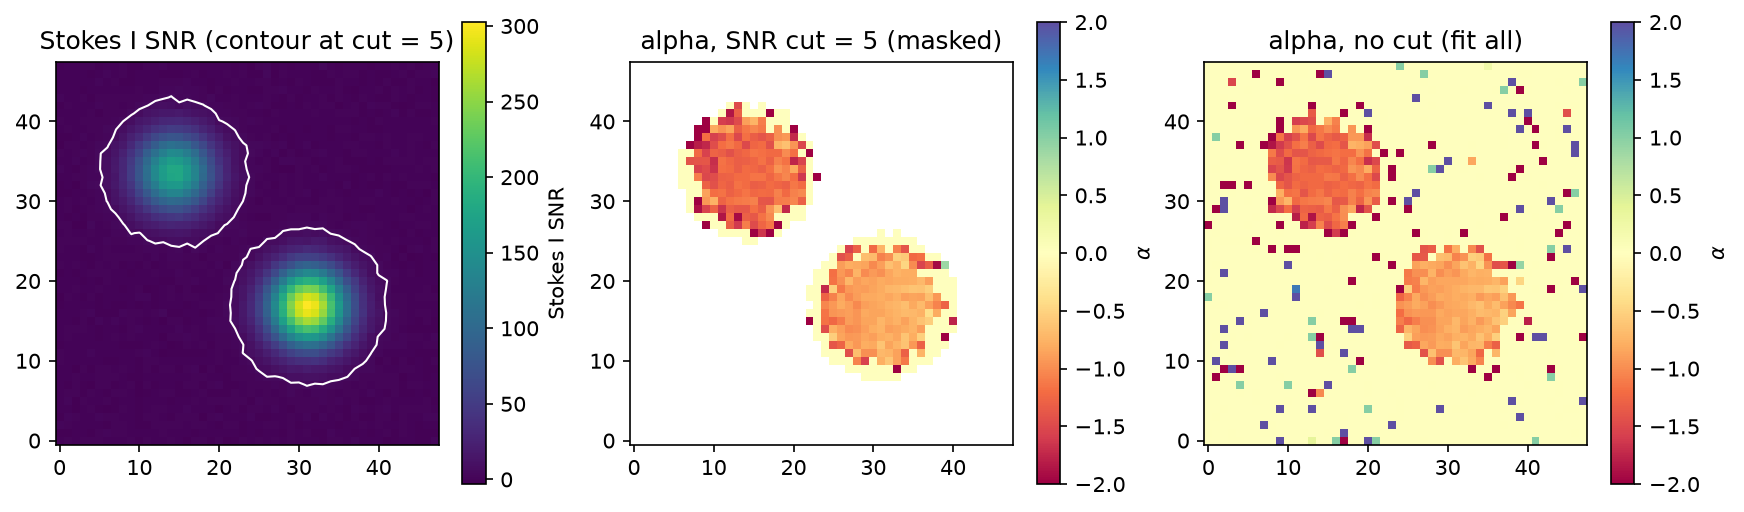

In [7]:
result_nomask = rmsynth_3d(
    da.from_array(stokes_q_obs, chunks=chunks),
    da.from_array(stokes_u_obs, chunks=chunks),
    freq_hz,
    stokes_i=da.from_array(stokes_i_obs, chunks=chunks),
    estimate_stokes_i_noise=True,
    fit_function="linear",
    fit_order=-2,
    stokes_i_snr_cut=None,  # no mask: fit every pixel
    phi_max_radm2=150.0,
    d_phi_radm2=1.0,
    weight_type="uniform",
)
alpha_nomask = result_nomask.stokes_i_alpha_map.compute()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4))
im1 = ax1.imshow(snr_map, origin="lower")
fig.colorbar(im1, ax=ax1, label="Stokes I SNR")
ax1.contour(snr_map, levels=[5.0], colors="w", linewidths=1)
ax1.set(title="Stokes I SNR (contour at cut = 5)")
im2 = ax2.imshow(alpha_map, origin="lower", cmap="Spectral", vmin=-2, vmax=2)
fig.colorbar(im2, ax=ax2, label=r"$\alpha$")
ax2.set(title="alpha, SNR cut = 5 (masked)")
im3 = ax3.imshow(alpha_nomask, origin="lower", cmap="Spectral", vmin=-2, vmax=2)
fig.colorbar(im3, ax=ax3, label=r"$\alpha$")
ax3.set(title="alpha, no cut (fit all)")

`rmsynth_3d_from_fits` takes the same Stokes I options as file paths (`stokes_i_file`, `stokes_i_error_file`, or `stokes_i_model_file`). A per-pixel model error cube is available with `compute_model_error=True` (a second fit pass). See the [3D RM-CLEAN](rmclean_3d.ipynb) page to deconvolve these cubes.